# SupplyMind AI — Dataset Understanding

In [ ]:
# -------------------
# Imports
# -------------------

from pathlib import Path

import pandas as pd

from supplymind.features.predictions.application.dataset import (
    load_tabular_dataset,
    normalize_column_names,
)

In [ ]:
# -------------------
# Dataset path
# -------------------

DATASET_PATH = Path("../data/raw/syndelay_v1.csv")

In [ ]:
# -------------------
# Load raw dataset
# -------------------

raw_df = load_tabular_dataset(DATASET_PATH)

raw_df.columns.tolist()
raw_df.dtypes
raw_df.head(30)

,payment_type,profit_per_order,sales_per_customer,category_id,category_name,customer_city,customer_country,customer_id,customer_segment,customer_state,...,order_region,order_state,order_status,product_card_id,product_category_id,product_name,product_price,shipping_date,shipping_mode,label
0,PAYMENT,-32.924488,278.95000,38,Kids' Golf Clubs,Caguas,Puerto Rico,12446.5625,Corporate,PR,...,Caribbean,Martinique,PENDING_PAYMENT,858,38,GolfBuddy VT3 GPS Watch,129.99,42177.500,Second Class,2
1,DEBIT,107.874500,263.98000,17,Cleats,Caguas,Puerto Rico,7782.0170,Corporate,PR,...,East Africa,Copperbelt,COMPLETE,365,17,Perfect Fitness Perfect Rip Deck,59.99,42502.390,Same Day,1
2,PAYMENT,35.770718,109.65013,17,Cleats,Caguas,Puerto Rico,7378.1113,Consumer,PR,...,West Asia,Ankara,PENDING_PAYMENT,365,17,Perfect Fitness Perfect Rip Deck,59.99,42951.266,Standard Class,0
3,PAYMENT,43.587560,113.09000,18,Men's Footwear,Caguas,Puerto Rico,1448.6765,Consumer,PR,...,Central America,Francisco Morazan,PENDING_PAYMENT,403,18,Nike Men's CJ Elite 2 TD Football Cleat,129.99,42181.900,Second Class,2
4,PAYMENT,49.804802,191.98090,9,Cardio Equipment,Madison,EE. UU.,5123.5254,Corporate,WI,...,Central America,Leon,PENDING_PAYMENT,191,9,Nike Men's Free 5.0+ Running Shoe,99.99,42632.820,Standard Class,1
5,PAYMENT,73.840120,168.22969,48,Water Sports,Caguas,Puerto Rico,11010.9795,Consumer,PR,...,South Asia,Mazandaran,PENDING_PAYMENT,1073,48,Pelican Sunstream 100 Kayak,199.99,42872.883,Second Class,2
6,TRANSFER,95.949814,284.98000,17,Cleats,Florissant,EE. UU.,10328.7110,Consumer,MO,...,US Center,Texas,PROCESSING,365,17,Perfect Fitness Perfect Rip Deck,59.99,42101.780,Standard Class,0
7,TRANSFER,18.990294,104.37533,9,Cardio Equipment,Pompano Beach,EE. UU.,9461.3550,Consumer,FL,...,Oceania,New South Wales,PENDING,191,9,Nike Men's Free 5.0+ Running Shoe,99.99,43011.060,First Class,2
8,CASH,59.853287,284.98000,43,Camping & Hiking,Elmhurst,EE. UU.,9096.2260,Consumer,IL,...,Northern Europe,England,CLOSED,957,43,Diamondback Women's Serene Classic Comfort Bi,299.98,42351.508,Standard Class,0
9,CASH,55.628014,141.38400,46,Indoor/Outdoor Games,Mount Pleasant,EE. UU.,12001.8680,Home Office,MI,...,Western Europe,Isle of France,CLOSED,1014,46,O'Brien Men's Neoprene Life Vest,49.98,42131.395,Standard Class,0


In [ ]:
# -------------------
# Basic profile
# -------------------

print(f"Rows: {len(raw_df):,}")
print(f"Columns: {raw_df.shape[1]:,}")
print(f"Memory usage: {raw_df.memory_usage(deep=True).sum() / 1_000_000:.2f} MB")

raw_df.info()

Rows: 155,488
Columns: 41
Memory usage: 75.47 MB
<class 'pandas.DataFrame'>
RangeIndex: 155488 entries, 0 to 155487
Data columns (total 41 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   payment_type              155488 non-null  str    
 1   profit_per_order          155488 non-null  float64
 2   sales_per_customer        155488 non-null  float64
 3   category_id               155488 non-null  int64  
 4   category_name             155488 non-null  str    
 5   customer_city             155488 non-null  str    
 6   customer_country          155488 non-null  str    
 7   customer_id               155488 non-null  float64
 8   customer_segment          155488 non-null  str    
 9   customer_state            155488 non-null  str    
 10  customer_zipcode          155488 non-null  float64
 11  department_id             155488 non-null  int64  
 12  department_name           155488 non-null  str    
 13  latitu

In [ ]:
raw_df.describe()

,profit_per_order,sales_per_customer,category_id,customer_id,customer_zipcode,department_id,latitude,longitude,order_customer_id,order_date,...,order_item_profit_ratio,order_item_quantity,sales,order_item_total_amount,order_profit_per_order,product_card_id,product_category_id,product_price,shipping_date,label
count,155488.000000,155488.000000,155488.000000,155488.000000,155488.000000,155488.000000,155488.000000,155488.000000,155488.000000,155488.000000,...,155488.000000,155488.000000,155488.000000,155488.000000,155488.000000,155488.000000,155488.000000,155488.000000,155488.000000,155488.000000
mean,22.625080,181.098027,31.642847,6681.724789,35840.444698,5.433641,29.784330,-84.722127,6642.201590,42534.882311,...,0.126187,2.125025,201.818054,181.253691,23.134572,687.903813,31.642847,139.148537,42538.406750,1.340766
std,119.818361,113.480905,15.597621,4112.453329,36827.395347,1.627307,9.695576,20.402017,4085.771174,302.327634,...,0.457384,1.445474,126.662042,114.731803,97.974173,335.986891,15.597621,133.748436,302.326223,0.834877
min,-4274.980000,7.780167,2.000000,2.000000,0.000000,2.000000,-33.937553,-158.025990,2.000000,42005.016000,...,-2.750000,1.000000,9.990000,7.492500,-3824.466045,19.000000,2.000000,9.990000,42005.652000,0.000000
25%,7.568531,105.570935,18.000000,3297.375900,725.000000,4.000000,18.266945,-97.668050,3272.024200,42274.645750,...,0.080000,1.000000,119.980000,103.992000,7.425000,403.000000,18.000000,50.000000,42278.233000,1.000000
50%,32.682004,165.948080,29.000000,6417.069250,20861.633000,5.000000,33.362042,-78.744316,6397.487550,42539.712500,...,0.270000,1.000000,199.920000,163.983600,32.172525,627.000000,29.000000,59.990000,42543.318000,2.000000
75%,64.366681,245.980000,45.000000,9735.472250,77048.682500,7.000000,39.109177,-66.370580,9672.004250,42787.679750,...,0.360000,3.000000,299.950000,245.983600,64.796760,1004.000000,45.000000,199.990000,42791.151500,2.000000
max,805.540160,1939.990000,76.000000,20757.000000,99205.000000,12.000000,48.781933,115.040000,20757.000000,43131.984000,...,0.500000,5.000000,1999.990000,1858.859300,799.931238,1363.000000,76.000000,1999.990000,43137.984000,2.000000


In [ ]:
# -------------------
# Column inventory
# -------------------

column_profile = pd.DataFrame({
    "column": raw_df.columns,
    "dtype": raw_df.dtypes.astype(str).values,
    "missing_count": raw_df.isna().sum().values,
    "missing_rate": raw_df.isna().mean().values,
    "unique_count": raw_df.nunique(dropna=True).values,
}).sort_values(
    by=["missing_rate", "unique_count"],
    ascending=[False, False],
)

column_profile

,column,dtype,missing_count,missing_rate,unique_count
1,profit_per_order,float64,0,0.0,152935
20,order_id,float64,0,0.0,152595
7,customer_id,float64,0,0.0,148992
24,order_item_id,float64,0,0.0,132436
18,order_customer_id,float64,0,0.0,132062
13,latitude,float64,0,0.0,124885
38,shipping_date,float64,0,0.0,118997
19,order_date,float64,0,0.0,118809
14,longitude,float64,0,0.0,91519
2,sales_per_customer,float64,0,0.0,85233


label
2    89709
0    36724
1    29055
Name: count, dtype: int64

label
2    0.58
0    0.24
1    0.19
Name: proportion, dtype: float64


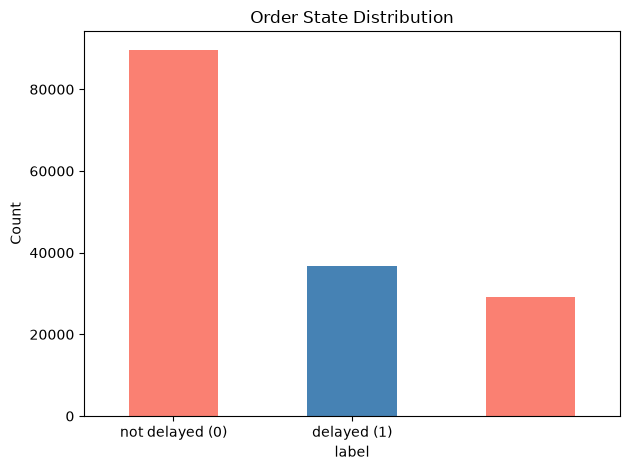

In [ ]:
import matplotlib.pyplot as plt

print(raw_df['label'].value_counts())
print()
print(raw_df['label'].value_counts(normalize=True).round(2))

raw_df['label'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'])
plt.xticks([0, 1], ['not delayed (0)', 'delayed (1)'], rotation=0)
plt.ylabel('Count')
plt.title('Order State Distribution')
plt.tight_layout()
plt.show()

In [ ]:
# -------------------
# Duplicate inspection
# -------------------

print(f"Exact duplicate rows: {raw_df.duplicated().sum():,}")

Exact duplicate rows: 0


In [ ]:
# -------------------
# Normalized column preview
# -------------------

normalized_df = normalize_column_names(raw_df)
list(normalized_df.columns)

['payment_type',
 'profit_per_order',
 'sales_per_customer',
 'category_id',
 'category_name',
 'customer_city',
 'customer_country',
 'customer_id',
 'customer_segment',
 'customer_state',
 'customer_zipcode',
 'department_id',
 'department_name',
 'latitude',
 'longitude',
 'market',
 'order_city',
 'order_country',
 'order_customer_id',
 'order_date',
 'order_id',
 'order_item_cardprod_id',
 'order_item_discount',
 'order_item_discount_rate',
 'order_item_id',
 'order_item_product_price',
 'order_item_profit_ratio',
 'order_item_quantity',
 'sales',
 'order_item_total_amount',
 'order_profit_per_order',
 'order_region',
 'order_state',
 'order_status',
 'product_card_id',
 'product_category_id',
 'product_name',
 'product_price',
 'shipping_date',
 'shipping_mode',
 'label']

In [ ]:
# -------------------
# Target distribution
# -------------------

raw_df["label"].value_counts(dropna=False)

raw_df["label"].value_counts(normalize=True).sort_index()

label
0    0.236185
1    0.186863
2    0.576951
Name: proportion, dtype: float64

In [ ]:
# -------------------
# Shipping mode distribution
# -------------------

raw_df["shipping_mode"].value_counts()

shipping_mode
Standard Class    92851
Second Class      31056
First Class       23622
Same Day           7959
Name: count, dtype: int64

In [ ]:
# -------------------
# Shipping mode vs target
# -------------------

shipping_label = pd.crosstab(
    raw_df["shipping_mode"],
    raw_df["label"],
    normalize="index"
)

shipping_label

label,0,1,2
shipping_mode,,,
First Class,0.000000,0.000000,1.000000
Same Day,0.000000,0.498178,0.501822
Second Class,0.000000,0.207367,0.792633
Standard Class,0.395515,0.200859,0.403625


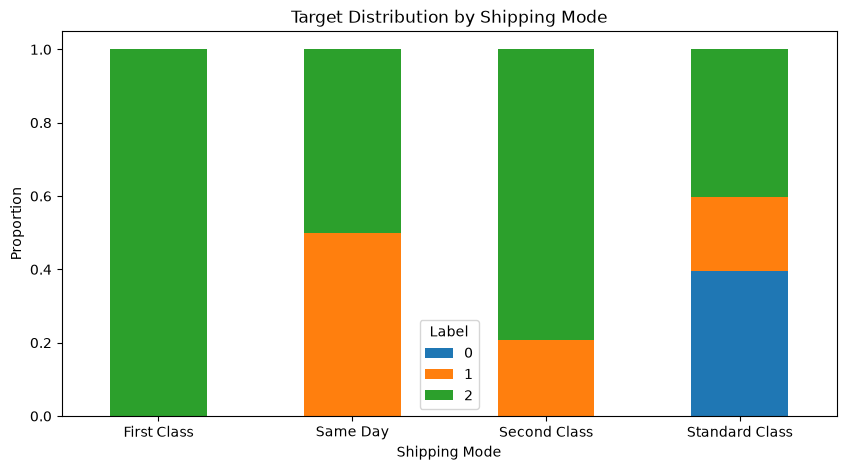

In [ ]:
# -------------------
# Shipping mode vs target plot
# -------------------

shipping_label.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
)

plt.title("Target Distribution by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Proportion")
plt.legend(title="Label")
plt.xticks(rotation=0)
plt.show()

In [ ]:
raw_df["shipping_mode"].value_counts(normalize=True).mul(100).round(2)

shipping_mode
Standard Class    59.72
Second Class      19.97
First Class       15.19
Same Day           5.12
Name: proportion, dtype: float64

In [ ]:
# -------------------
# Shipping mode vs target
# -------------------

shipping_target = pd.crosstab(
    raw_df["shipping_mode"],
    raw_df["label"]
)

shipping_target

label,0,1,2
shipping_mode,,,
First Class,0,0,23622
Same Day,0,3965,3994
Second Class,0,6440,24616
Standard Class,36724,18650,37477


In [ ]:
# -------------------
# Shipping mode and order status
# -------------------

print(raw_df["shipping_mode"].value_counts())
print()

print(raw_df["order_status"].value_counts())
print()

print(raw_df["label"].value_counts())

shipping_mode
Standard Class    92851
Second Class      31056
First Class       23622
Same Day           7959
Name: count, dtype: int64

order_status
COMPLETE           53301
PENDING_PAYMENT    36398
PROCESSING         20025
PENDING            17810
CLOSED             17504
ON_HOLD             9264
PAYMENT_REVIEW      1186
Name: count, dtype: int64

label
2    89709
0    36724
1    29055
Name: count, dtype: int64


In [ ]:
# -------------------
# Shipping mode vs target
# -------------------

shipping_vs_target = pd.crosstab(
    raw_df["shipping_mode"],
    raw_df["label"],
    normalize="index"
).mul(100).round(2)

shipping_vs_target

label,0,1,2
shipping_mode,,,
First Class,0.00,0.00,100.00
Same Day,0.00,49.82,50.18
Second Class,0.00,20.74,79.26
Standard Class,39.55,20.09,40.36


In [ ]:
# -------------------
# Order status vs target
# -------------------

status_vs_target = pd.crosstab(
    raw_df["order_status"],
    raw_df["label"],
    normalize="index"
).mul(100).round(2)

status_vs_target

label,0,1,2
order_status,,,
CLOSED,24.02,18.66,57.31
COMPLETE,23.36,18.97,57.67
ON_HOLD,24.31,19.11,56.58
PAYMENT_REVIEW,22.43,19.56,58.01
PENDING,23.36,18.37,58.27
PENDING_PAYMENT,23.47,18.47,58.06
PROCESSING,24.21,18.37,57.42


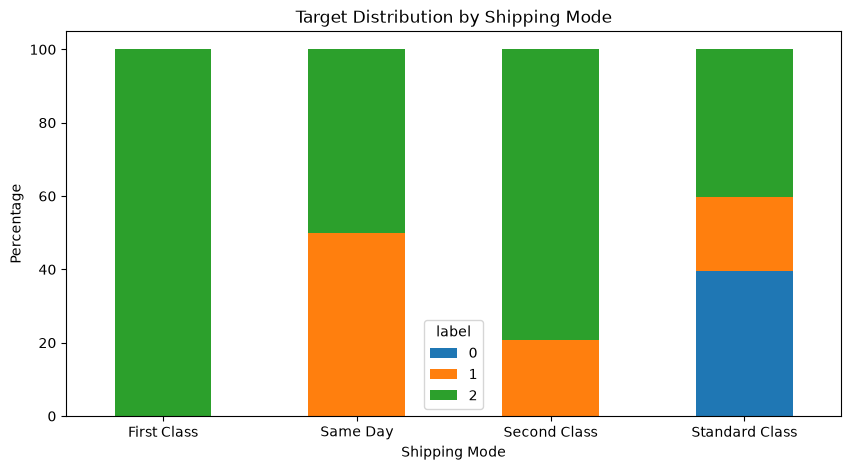

In [ ]:
# -------------------
# Shipping mode vs target
# -------------------

shipping_vs_target.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Target Distribution by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

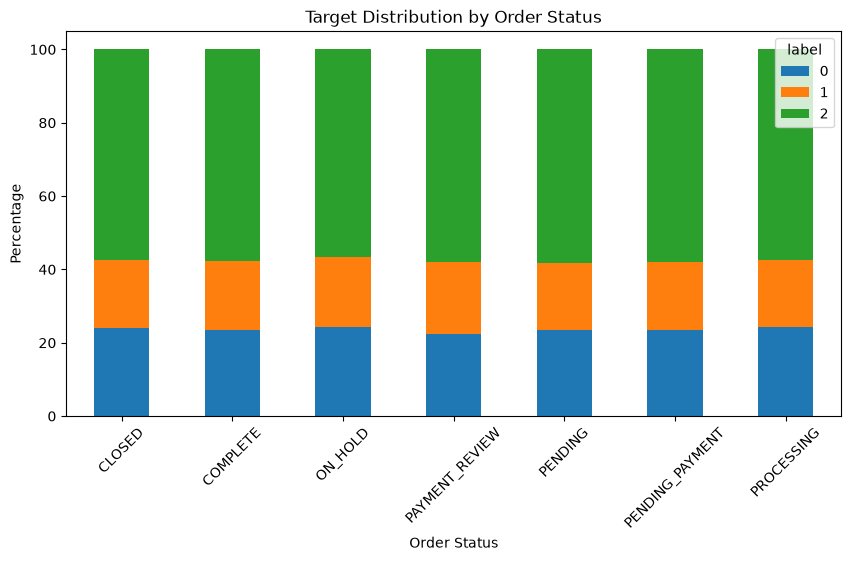

In [ ]:
# -------------------
# Order status vs target
# -------------------

status_vs_target.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Target Distribution by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# -------------------
# Missing values
# -------------------

missing = (
    raw_df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

Series([], dtype: int64)

In [ ]:
# -------------------
# Cardinality
# -------------------

cardinality = (
    raw_df.nunique()
    .sort_values(ascending=False)
)

cardinality

profit_per_order            152935
order_id                    152595
customer_id                 148992
order_item_id               132436
order_customer_id           132062
latitude                    124885
shipping_date               118997
order_date                  118809
longitude                    91519
sales_per_customer           85233
customer_zipcode             82241
order_profit_per_order       48617
order_item_profit_ratio      17350
order_item_total_amount       7802
order_item_cardprod_id        7023
order_item_discount           6929
sales                         3718
order_item_product_price      3597
product_price                 3597
order_city                    3505
order_item_discount_rate      2321
order_state                   1054
customer_city                  563
order_country                  161
product_card_id                118
product_name                   118
category_id                     51
product_category_id             51
category_name       

In [ ]:
# -------------------
# Investigate target construction
# -------------------

[
    column
    for column in raw_df.columns
    if any(
        keyword in column.lower()
        for keyword in ["ship", "delivery", "day", "date", "label"]
    )
]

['order_date', 'shipping_date', 'shipping_mode', 'label']

In [ ]:
# -------------------
# Shipping mode counts by target
# -------------------

pd.crosstab(
    raw_df["shipping_mode"],
    raw_df["label"],
    margins=True
)

label,0,1,2,All
shipping_mode,,,,
First Class,0,0,23622,23622
Same Day,0,3965,3994,7959
Second Class,0,6440,24616,31056
Standard Class,36724,18650,37477,92851
All,36724,29055,89709,155488
